# Internship Task 1: Linear Regression on California Housing Dataset

**Objective:** Build and evaluate a Linear Regression model using the California Housing dataset from scikit-learn.

This notebook is designed for beginners. It goes step-by-step through the machine learning pipeline:
1. **Importing Libraries**
2. **Loading the Dataset**
3. **Exploratory Data Analysis (EDA)**
4. **Data Preprocessing**
5. **Model Training**
6. **Model Evaluation**
7. **Saving the Model**

## 1. Importing Required Libraries
We start by importing the necessary libraries for data manipulation, visualization, and machine learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# Set visualization style
sns.set_theme(style="whitegrid")

## 2. Loading the Dataset
We will load the California Housing dataset directly from `sklearn.datasets` and convert it into a Pandas DataFrame for easier manipulation.

In [16]:
# Fetch dataset
california_data = fetch_california_housing()

# Create a Pandas DataFrame
df = pd.DataFrame(california_data.data, columns=california_data.feature_names)

# Add the target variable (median house value) to the DataFrame
df['MedHouseVal'] = california_data.target

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)
EDA helps us understand our data before feeding it into a machine learning model.

### 3.1. Dataset Overview, Shape, and Data Types

In [17]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Dataset Shape: (20640, 9)

Data Types:
 MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


### 3.2. Descriptive Statistics

In [18]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 3.3. Missing Value Analysis
It is crucial to check for missing values, as they can cause errors during model training.

In [19]:
print("Missing values in each column:\n", df.isnull().sum())

Missing values in each column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### 3.4. Visualizations: Histograms
Let's look at the distribution of our target variable `MedHouseVal` and other features.

<Figure size 1200x1000 with 0 Axes>

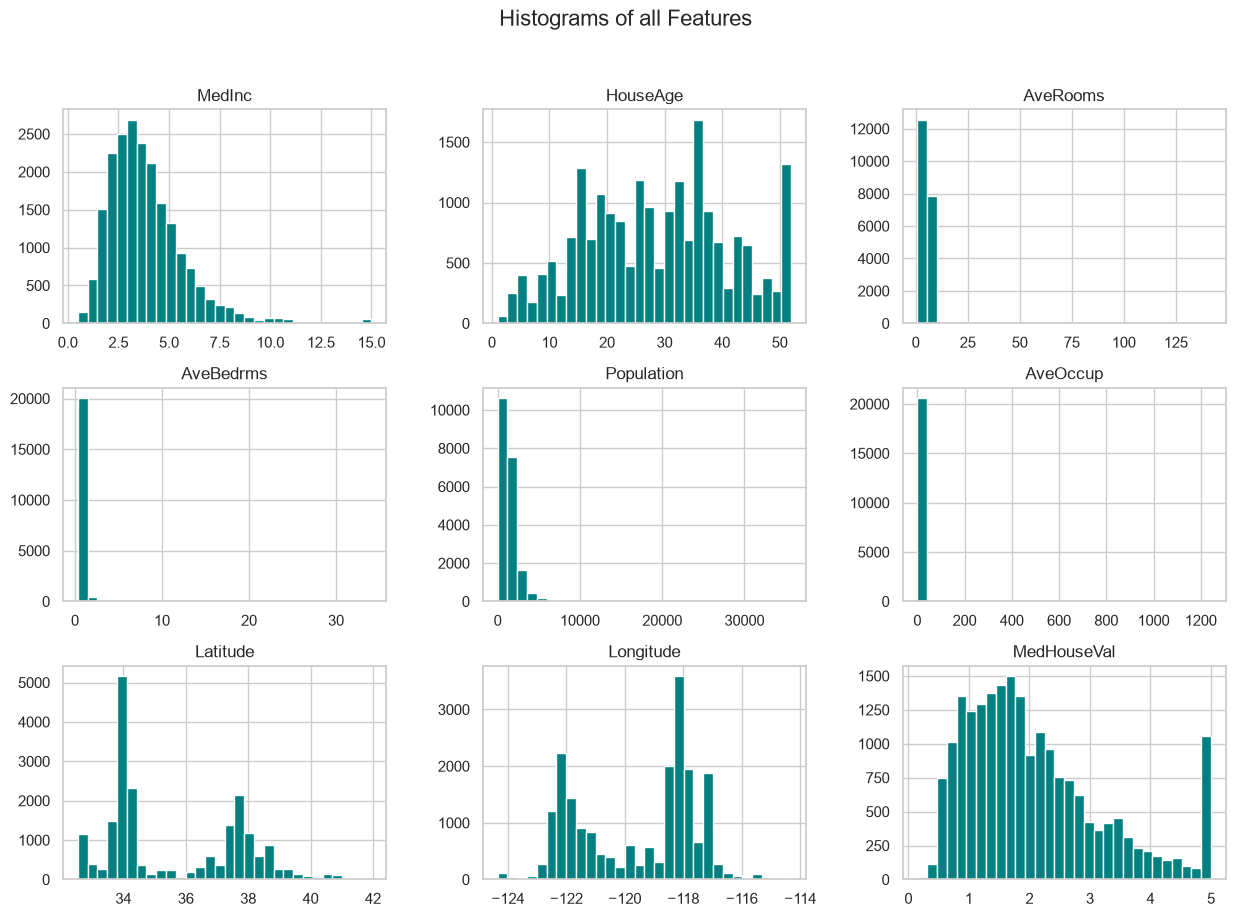

In [20]:
plt.figure(figsize=(12, 10))
df.hist(bins=30, figsize=(15, 10), color='teal')
plt.suptitle('Histograms of all Features', fontsize=16)
plt.show()

### 3.5. Visualizations: Correlation Matrix & Heatmap
A correlation matrix helps us understand how features relate to the target variable and to each other.

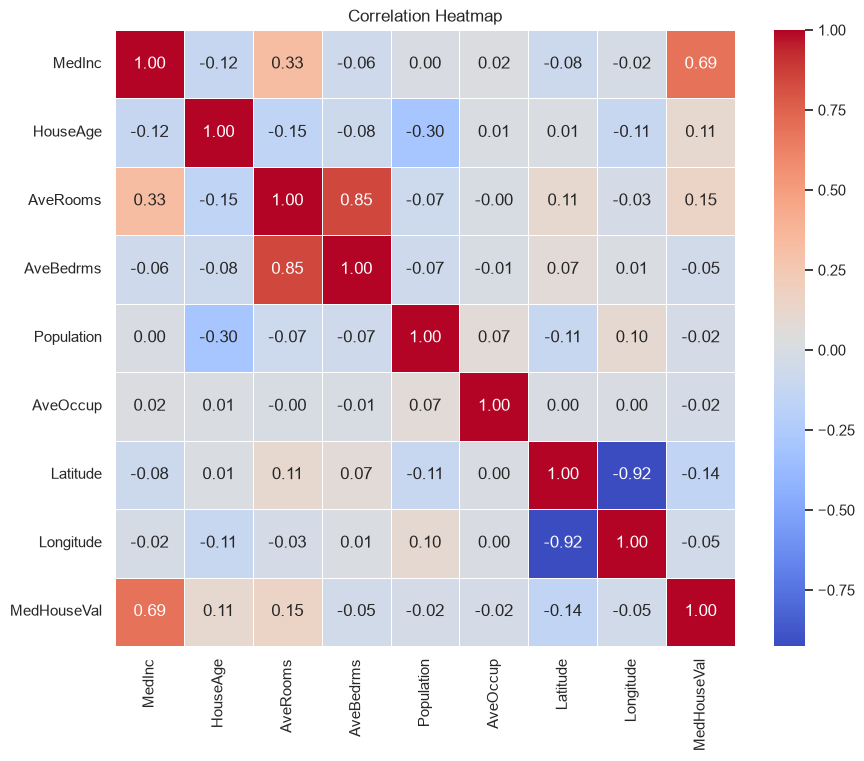

In [21]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Observation**: `MedInc` (Median Income) has the highest positive correlation with `MedHouseVal` (House Value).

### 3.6. Visualizations: Scatter Plots
Let's visualize the relationship between Median Income and House Value.

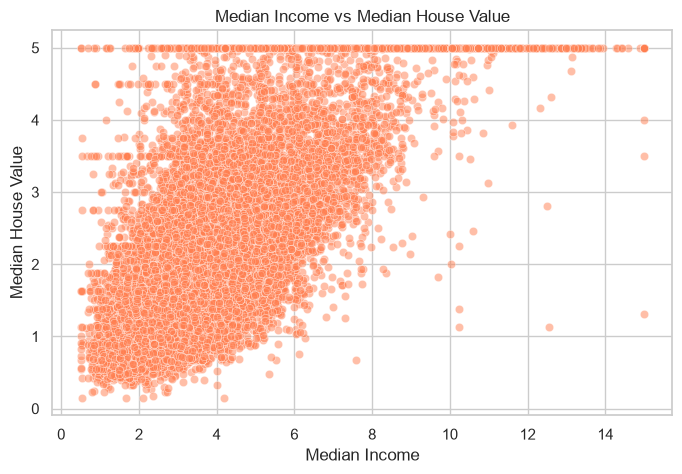

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.5, color='coral')
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

### 3.7. Visualizations: Box Plots
Box plots are useful for detecting outliers.

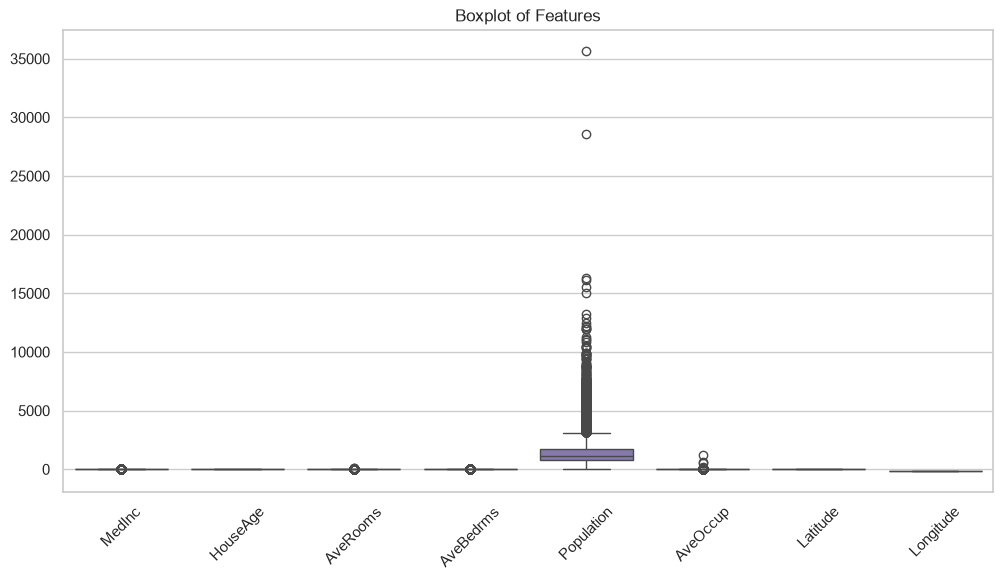

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop('MedHouseVal', axis=1))
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.show()

## 4. Data Splitting
We will separate our features (X) and target variable (y). Then, we split the data into a training set (80%) and a testing set (20%).

In [24]:
# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


## 5. Model Training
We will initialize the Linear Regression model and train it using our training data.

In [25]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## 6. Model Evaluation
Now we use the trained model to make predictions on the test set and evaluate its performance using metrics:
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual values. Lower is better.
- **RMSE (Root Mean Squared Error):** Square root of the average squared differences. Penalizes large errors more. Lower is better.
- **R² Score:** Proportion of variance in the target variable explained by the model. Closer to 1 is better.

In [26]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


### 6.1. Actual vs. Predicted Visualization

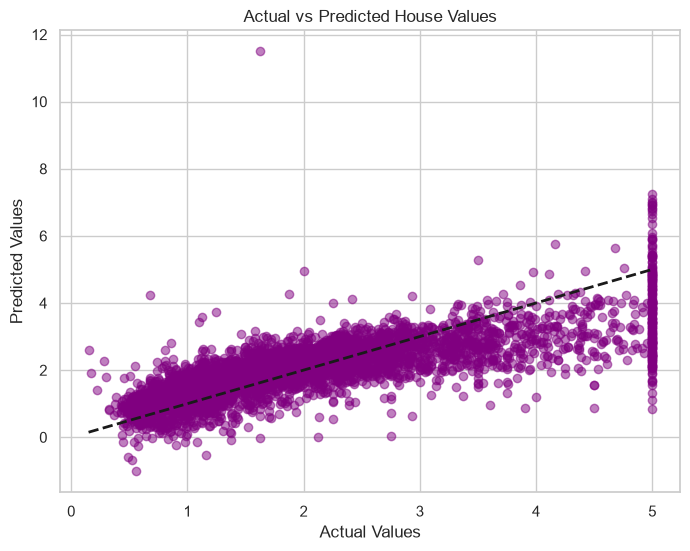

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted House Values')
plt.show()

## 7. Saving the Model
We can save our trained model to a file using `pickle`. This allows us to load and use the model later without retraining.

In [28]:
# Save the model to a .pkl file
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as linear_regression_model.pkl")

Model saved as linear_regression_model.pkl


## Conclusion
We successfully loaded the data, performed EDA, trained a Linear Regression model, and evaluated its performance. This forms the baseline for more complex machine learning models.